In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import math

import plotly.io as pio
pio.renderers.default = "browser"

In [ ]:
def solve_and_plot(system, t_span, initial_conditions, t_eval=None, grid_size=20, time_points=1000, rtol=1e-9, atol=1e-12, max_step=np.inf, fixed_points = None):
    """
    Solve and visualize a 2D or 3D nonlinear dynamical system with higher time resolution.

    Parameters:
    - system: function(t, y) -> list/array
    - t_span: tuple (t0, tf)
    - initial_conditions: array-like of shape (N, dim)
    - t_eval: optional array of time points (overrides time_points if provided)
    - grid_size: resolution of vector field grid
    - time_points: number of time samples if t_eval is None
    - rtol, atol: solver tolerances (tighter = higher accuracy)
    - max_step: maximum internal solver step size (reduce for finer resolution)
    """

    initial_conditions = np.array(initial_conditions)
    dim = initial_conditions.shape[1]

    if dim not in [2, 3]:
        raise ValueError("Only 2D or 3D systems are supported.")

    # --- Build high-resolution time grid if not provided ---
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], time_points)

    # --- First: integrate trajectories to determine bounds ---
    trajectories = []
    all_points = []

    for y0 in initial_conditions:
        sol = solve_ivp(
            system,
            t_span,
            y0,
            t_eval=t_eval,
            rtol=rtol,
            atol=atol,
            max_step=max_step
        )
        trajectories.append(sol)
        all_points.append(sol.y.T)

    all_points = np.vstack(all_points)

    # Determine dynamic plotting bounds based on trajectories
    mins = all_points.min(axis=0)
    maxs = all_points.max(axis=0)

    # Add margin so vectors are not clipped
    margins = 0.1 * (maxs - mins + 1e-6)
    mins -= margins
    maxs += margins

    # --- Generate vector field grid using trajectory-informed bounds ---
    ranges = [np.linspace(mins[d], maxs[d], grid_size) for d in range(dim)]
    mesh = np.meshgrid(*ranges)

    # Flatten grid for evaluation
    points = np.vstack([m.flatten() for m in mesh]).T
    vectors = np.array([system(0, p) for p in points])

    # --- Plotting ---
    fig = plt.figure(figsize=(8, 6))

    if dim == 2:
        X, Y = mesh
        U = vectors[:, 0].reshape(X.shape)
        V = vectors[:, 1].reshape(Y.shape)

        plt.quiver(X, Y, U, V, alpha=0.6)

        # Plot trajectories
        for sol, y0 in zip(trajectories, initial_conditions):
            plt.plot(sol.y[0], sol.y[1])
            plt.scatter(y0[0], y0[1])
        
        if fixed_points is not None:
            for fixed_point in fixed_points:
                if fixed_point[0] == 'stable':
                    plt.scatter(fixed_point[1][0], fixed_point[1][1], c='k', s=30)
                elif fixed_point[0] == 'unstable':
                    plt.scatter(fixed_point[1][0], fixed_point[1][1], facecolor='white', edgecolor='black', s=30)

        plt.xlim(mins[0], maxs[0])
        plt.ylim(mins[1], maxs[1])
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Phase Space (2D)')
        plt.grid()

    elif dim == 3:
        from mpl_toolkits.mplot3d import Axes3D
        ax = fig.add_subplot(111, projection='3d')

        X, Y, Z = mesh
        U = vectors[:, 0].reshape(X.shape)
        V = vectors[:, 1].reshape(Y.shape)
        W = vectors[:, 2].reshape(Z.shape)

        ax.quiver(X, Y, Z, U, V, W, length=0.5, normalize=True, alpha=0.5)

        # Plot trajectories
        for sol, y0 in zip(trajectories, initial_conditions):
            ax.plot(sol.y[0], sol.y[1], sol.y[2])
            ax.scatter(y0[0], y0[1], y0[2])

        if fixed_points is not None:
            for fixed_point in fixed_points:
                if fixed_point[0] == 'stable':
                    ax.scatter(fixed_point[1][0], fixed_point[1][1], fixed_point[1][2], c='k', s=30)
                elif fixed_point[0] == 'unstable':
                    ax.scatter(fixed_point[1][0], fixed_point[1][1], fixed_point[1][2], facecolor='white', edgecolor='black', s=30)

        ax.set_xlim(mins[0], maxs[0])
        ax.set_ylim(mins[1], maxs[1])
        ax.set_zlim(mins[2], maxs[2])
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title('Phase Space (3D)')

    plt.tight_layout()
    plt.show()


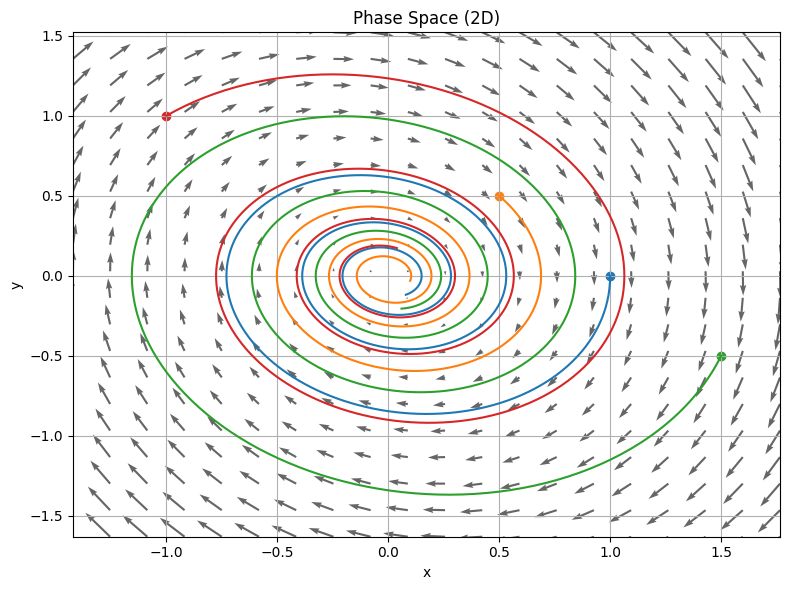

In [84]:
def system(t, y, zeta=0.1):
    """
    Dimensionless damped harmonic oscillator:

        x'' + 2*zeta*x' + x = 0

    Converted to first-order system:
        x' = v
        v' = -2*zeta*v - x

    Parameters:
    - zeta: damping ratio
    """
    x, v = y
    dxdt = v
    dvdt = -2 * zeta * v - x
    return [dxdt, dvdt]

#Example initial conditions (for notebook use):
initial_conditions = [
     [1.0, 0.0],
    [0.5, 0.5],
    [1.5, -0.5],
    [-1.0, 1.0]
]



#Example call (in notebook):
solve_and_plot(system, t_span=(0, 20), initial_conditions=initial_conditions)

now with driving

In [89]:
zeta=0.1
A=5
delta=-4

def system(t, y):
    """
    Dimensionless damped harmonic oscillator:

        x'' + 2*zeta*x' + x = 0

    Converted to first-order system:
        x' = v
        v' = -2*zeta*v - x

    Parameters:
    - zeta: damping ratio
    """
    x, v = y
    dxdt = v
    dvdt = -2 * zeta * v - x + A / ((x+delta)**2+1)
    return [dxdt, dvdt]

In [91]:
def x_star(A, delta, branch_shift):
    roots = np.roots([1, 2*delta, delta**2 + 1, -A])
    roots[~np.isreal(roots)] = np.nan

    # stabilize branch selection via continuous shift
    return np.real(roots)


In [ ]:
roots = x_star(A, delta, 0)

fixed_points = []

for x in roots:
    if not np.isnan(x):
        eigenvalues, eigenvectors = np.linalg.eig(np.array([[0, 1],
                                              [-1 - 2*A*(x+delta) / ((x+delta)**2+1)**2, -2*zeta]]))
        if np.real(eigenvalues)[0] < 0 and np.real(eigenvalues)[1] < 0:
            fixed_points.append(('stable', (x, 0)))
        else:
            fixed_points.append(('unstable', (x, 0)))

fixed_points
    

[('stable', np.float64(4.37720285397294)),
 ('unstable', np.float64(3.273890554964227)),
 ('stable', np.float64(0.3489065910628246))]

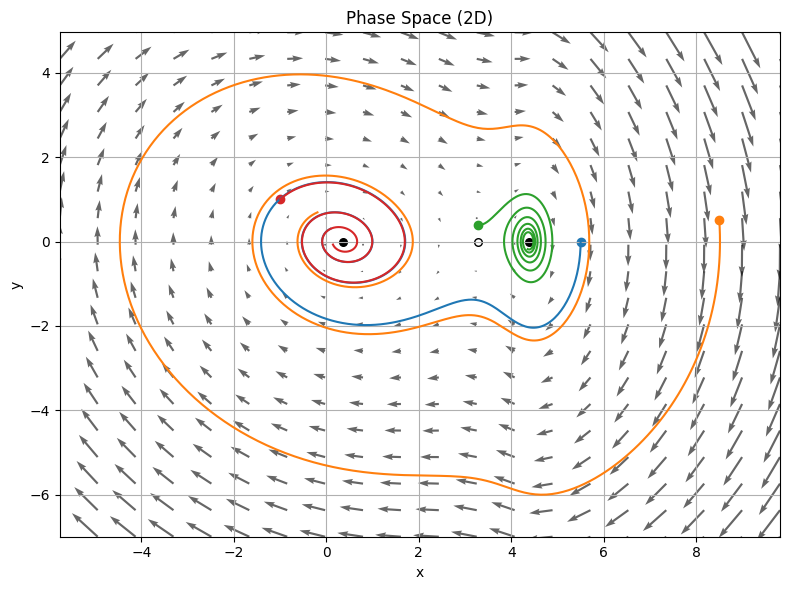

In [99]:
#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0],
    [8.5, 0.5],
    [3.27, 0.4],
    [-1.0, 1.0]
]


solve_and_plot(system, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points)

3.8851326820537975
[-0.1+0.33026329j -0.1-0.33026329j]
3.851824575229439
[ 0.25632485 -0.45632485]
0.2630427427167583
[-0.1+0.92662194j -0.1-0.92662194j]


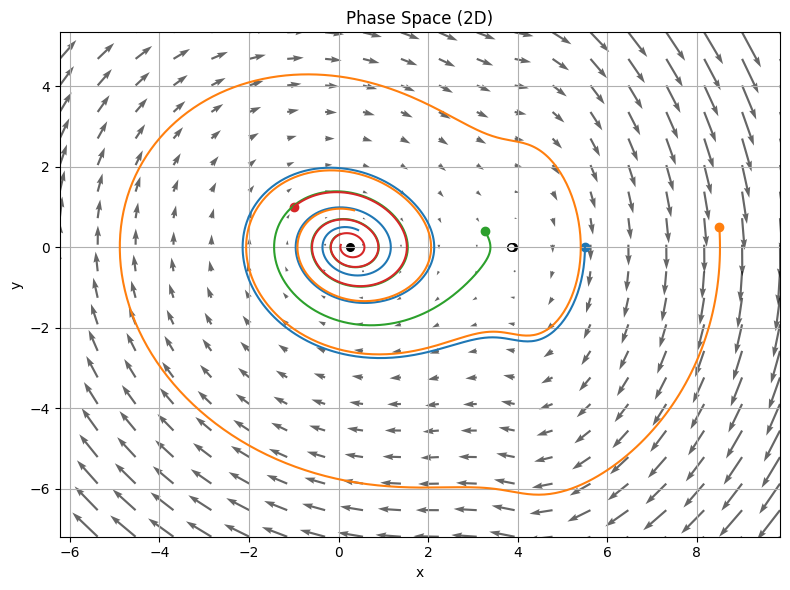

In [ ]:
def bifurcation(d):
    return 2/27 * (-1*(d**3+9*d) + (3-d**2)*np.sqrt(d**2 - 3))

zeta=0.1
delta=-4
A = bifurcation(delta)+0.001

#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0],
    [8.5, 0.5],
    [3.27, 0.4],
    [-1.0, 1.0]
]

roots = x_star(A, delta, 0)

fixed_points = []

for x in roots:
    print(x)
    if not np.isnan(x):
        eigenvalues, eigenvectors = np.linalg.eig(np.array([[0, 1],
                                              [-1 - 2*A*(x+delta) / ((x+delta)**2+1)**2, -2*zeta]]))
        print(eigenvalues)
        if np.real(eigenvalues)[0] < 0 and np.real(eigenvalues)[1] < 0:
            fixed_points.append(('stable', (x, 0)))
        else:
            fixed_points.append(('unstable', (x, 0)))

fixed_points


solve_and_plot(system, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points)

In [106]:
def bifurcation_plot(A_range, delta_range, resolution=150):

    A = np.linspace(*A_range, resolution)
    D = np.linspace(*delta_range, resolution)

    A_mesh, D_mesh = np.meshgrid(A, D)

    # IMPORTANT: treat each branch as its own parametric surface
    Z1 = np.full_like(A_mesh, np.nan, dtype=float)
    Z2 = np.full_like(A_mesh, np.nan, dtype=float)
    Z3 = np.full_like(A_mesh, np.nan, dtype=float)

    for i in range(resolution):
        for j in range(resolution):

            a = A_mesh[i, j]
            d = D_mesh[i, j]

            roots = np.roots([1, 2*d, d**2 + 1, -a])
            roots = np.real(roots[np.isreal(roots)])
            roots.sort()

            if len(roots) == 1:
                Z1[i, j] = roots[0]

            elif len(roots) == 3:
                Z3[i, j] = roots[0]
                Z2[i, j] = roots[1]
                Z1[i, j] = roots[2]

            #elif len(roots) == 2:
             #   Z1[i, j] = roots[0]
             #   Z2[i, j] = roots[1]


    Z1 = np.where(np.isfinite(Z1), Z1, np.nan)
    Z2 = np.where(np.isfinite(Z2), Z2, np.nan)
    Z3 = np.where(np.isfinite(Z3), Z3, np.nan)
    

    all_vals = np.concatenate([
        Z1[np.isfinite(Z1)].ravel(),
        Z2[np.isfinite(Z2)].ravel(),
        Z3[np.isfinite(Z3)].ravel()
    ])

    cmin = np.min(all_vals)
    cmax = np.max(all_vals)

    fig = go.Figure()

    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z1, colorscale="Reds",    cmin=cmin,    cmax=cmax, showscale=False))
    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z2, colorscale="Greens",    cmin=cmin,    cmax=cmax, showscale=False))
    fig.add_trace(go.Surface(x=A_mesh, y=D_mesh, z=Z3, colorscale="Blues",    cmin=cmin,    cmax=cmax, showscale=False))

    fig.update_layout(
        title="Clean Bifurcation Surfaces (Branch-Separated Parametric Form)",
        scene=dict(
            xaxis_title="A",
            yaxis_title="delta",
            zaxis_title="x*"
        )
    )

    fig.show()
    

In [107]:
bifurcation_plot(A_range=(0, 5), delta_range=(-6, 6), resolution=200)

In [ ]:
zeta=0.1
A=5
delta=-4
tau = 5

def system(t, y):
    """
    Dimensionless damped harmonic oscillator:

        x'' + 2*zeta*x' + x = 0

    Converted to first-order system:
        x' = v
        v' = -2*zeta*v - x

    Parameters:
    - zeta: damping ratio
    """
    x, v, z = y
    dxdt = v
    dvdt = -2 * zeta * v - x + z
    dzdt = A / ((x+delta)**2+1) - z/tau
    return [dxdt, dvdt, dzdt]

def x_star(A, delta, branch_shift):
    roots = np.roots([1, 2*delta, delta**2 + 1, -A])
    roots[~np.isreal(roots)] = np.nan

    # stabilize branch selection via continuous shift
    return np.real(roots)

#Example initial conditions (for notebook use):
initial_conditions = [
    [5.5, 0.0],
    [8.5, 0.5],
    [3.27, 0.4],
    [-1.0, 1.0]
]


solve_and_plot(system, t_span=(0, 20), initial_conditions=initial_conditions, fixed_points=fixed_points)
